## Imports


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dustmaps.planck import fetch as fetch_planck, PlanckQuery
from dustmaps.bayestar import BayestarQuery
from dustmaps.decaps import DECaPSQueryLite
from astropy.coordinates import SkyCoord, galactocentric_frame_defaults
from astropy import units as u
from scipy.stats import truncexpon

from gaianir_open_clusters import plots
from gaianir_open_clusters.dust import PlanckQuery3D

plots.setup_matplotlib(no_log=True)

In [2]:
# fetch_planck()

In [3]:
planck = PlanckQuery()
planck_3d = PlanckQuery3D()
bayestar = BayestarQuery(max_samples=1)
decaps = DECaPSQueryLite(mean_only=True)

Loading pixel_info ...
Loading samples ...
Loading best_fit ...
Replacing NaNs in reliable distance estimates ...
Sorting pixel_info ...
Extracting hp_idx_sorted and data_idx at each nside ...
  nside = 64
  nside = 128
  nside = 256
  nside = 512
  nside = 1024
t = 13.554 s
  pix_info:   0.194 s
   samples:   1.174 s
      best:   0.878 s
       nan:   0.011 s
      sort:  11.192 s
       idx:   0.104 s
Loading meta pixel info...
Meta pixel info loaded!


## A first look at the Planck map


In [ ]:
x_values = np.linspace(-180, 180, endpoint=False, num=500)
y_values = np.linspace(-50, 50, num=500)
x, y = [array.flatten() for array in np.meshgrid(x_values, y_values)]

coords = SkyCoord(l=x * u.deg, b=y * u.deg, distance=25 * u.kpc, frame="galactic")

planck_dust = 3.1 * planck.query(coords).reshape(y_values.size, x_values.size)

bayestar_dust = (
    3.1
    * 0.84
    * bayestar.query(coords, mode="best").reshape(y_values.size, x_values.size)
)
decaps_dust = 3.1 * decaps.query(coords).reshape(y_values.size, x_values.size)

combined_dust = np.where(np.isfinite(decaps_dust), decaps_dust, bayestar_dust)


Text(0.02, 0.6, '$b$ [deg]')

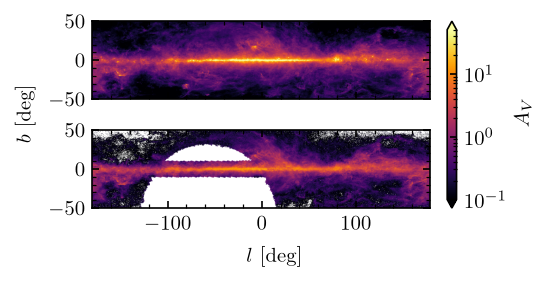

In [16]:
fig, ax = plt.subplots(
    nrows=2, figsize=(plots.COLWIDTH, plots.COLWIDTH * 0.5), sharex=True
)

common = dict(
    origin="lower",
    norm="log",
    cmap="inferno",
    vmin=0.1,
    vmax=50,
    extent=(x_values.min(), x_values.max(), y_values.min(), y_values.max()),
)

image = ax[0].imshow(planck_dust, **common)
ax[1].imshow(combined_dust, **common)

for an_ax in ax:
    an_ax.set_aspect("auto")
    an_ax.invert_xaxis()

fig.colorbar(image, ax=ax, extend="both", orientation="vertical", label="$A_V$")

fig.supxlabel("$l$ [deg]", fontsize=10)
fig.supylabel("$b$ [deg]", fontsize=10, y=0.6)

Funnily enough, I don't think that's clearer than just showing one

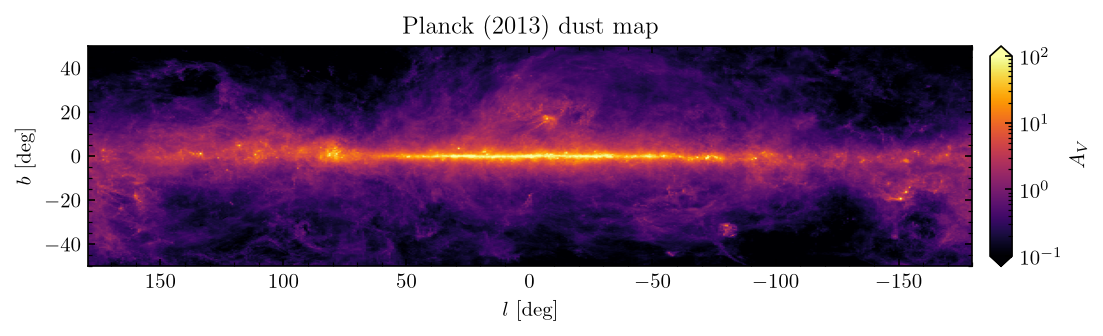

In [46]:
fig, ax = plt.subplots(figsize=(plots.TEXTWIDTH, plots.COLWIDTH*0.6))

common = dict(
    origin="lower",
    norm="log",
    cmap="inferno",
    vmin=0.1,
    vmax=100,
    extent=(x_values.min(), x_values.max(), y_values.min(), y_values.max()),
)

image = ax.imshow(planck_dust, **common)
ax.set_aspect("auto")
ax.invert_xaxis()

cax = fig.colorbar(
    image,
    ax=ax,
    extend="both",
    orientation="vertical",
    label="$A_V$",
    aspect=10,
    pad=0.02,
)


ax.set(xlabel="$l$ [deg]", ylabel="$b$ [deg]", title="Planck (2013) dust map")

fig.savefig(plots.FIGS_PRES / "planck_map.png")

## In 3D


In [62]:
SkyCoord(ra=0*u.deg, dec=0*u.deg, distance=0*u.pc).transform_to("galactocentric").z

<Quantity 20.8 pc>

In [67]:
resolution = 200

xy_range = 8000
x_center = -6000

x_values = np.linspace(
    -xy_range + x_center, xy_range + x_center, endpoint=False, num=resolution
)
y_values = np.linspace(-xy_range, xy_range, num=resolution)

x, y = [array.flatten() for array in np.meshgrid(x_values, y_values)]
z = np.zeros(len(x)) - 20.8

coords = SkyCoord(
    x=x * u.pc,
    y=y * u.pc,
    z=z * u.pc,
    frame="galactocentric",
    representation_type="cartesian",
)

In [140]:
# planck_dust = planck_3d.query(coords).reshape(resolution, resolution)
planck_dust_expon = 3.1 * planck_3d.query(coords, mode="expon").reshape(
    resolution, resolution
)
bayestar_dust = (
    3.1 * 0.84 * bayestar.query(coords, mode="best").reshape(resolution, resolution)
)
decaps_dust = 3.1 * decaps.query(coords).reshape(resolution, resolution)

In [143]:
base_dust = np.where(np.isfinite(decaps_dust), decaps_dust, bayestar_dust)
base_dust = np.where(np.isfinite(base_dust), base_dust, 0.1)
max_dust_expon = np.where(planck_dust_expon > base_dust, planck_dust_expon, base_dust)

/tmp/ipykernel_116176/3147281373.py:25: RuntimeWarning: divide by zero encountered in divide
  image_ratio = ax[3].imshow(max_dust_expon / base_dust, extent=extent, vmin=1, vmax=10)


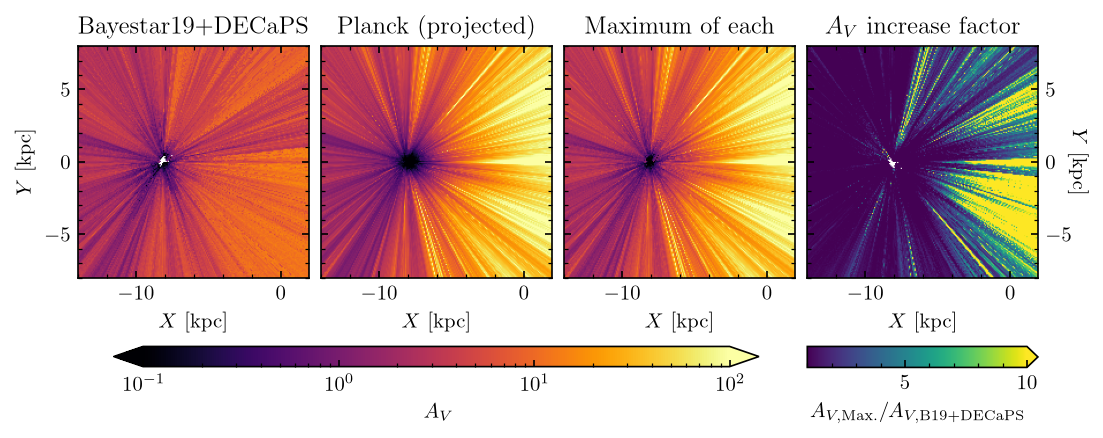

In [148]:
fig, ax = plt.subplots(
    ncols=4,
    figsize=(plots.TEXTWIDTH, plots.TEXTWIDTH * 0.38),
    sharex=True,
    sharey=True,
)

# max_dust = planck_dust.max()
max_dust = 100

extent = [
    x_values.min() * 1e-3,
    x_values.max() * 1e-3,
    y_values.min() * 1e-3,
    y_values.max() * 1e-3,
]

common_kwargs = dict(
    origin="lower", vmin=0.1, vmax=max_dust, cmap="inferno", extent=extent, norm="log"
)

ax[0].imshow(base_dust, **common_kwargs)
ax[1].imshow(planck_dust_expon, **common_kwargs)
image = ax[2].imshow(max_dust_expon, **common_kwargs)
image_ratio = ax[3].imshow(max_dust_expon / base_dust, extent=extent, vmin=1, vmax=10)

fig.colorbar(
    image,
    ax=ax[:-1],
    orientation="horizontal",
    aspect=32,
    label="$A_V$",
    extend="both",
    shrink=0.9,
)
fig.colorbar(
    image_ratio,
    ax=ax[-1],
    orientation="horizontal",
    aspect=11,
    label=r"$A_{V,\text{Max.}} / A_{V,\text{B19+DECaPS}}$",
    extend="max",
    # pad=0.08,
)

ax[0].set(title="Bayestar19+DECaPS", ylabel="$Y$ [kpc]")
ax[1].set(title="Planck (projected)")
ax[2].set(title="Maximum of each")
ax[3].set(title="$A_V$ increase factor")

for an_ax in ax:
    an_ax.set(xlabel="$X$ [kpc]")

ax[3].set_ylabel("$Y$ [kpc]", labelpad=-125, rotation=-90)
ax[3].tick_params(labelright=True)
# ax[0].scatter(x, y, c=decaps_dust, s=5, norm="log", vmax=100)

# ax[1].scatter(x, y, c=planck_dust, s=5, norm="log", vmax=100)

fig.savefig(plots.FIGS_PRES / "planck_map_3d.png")

## Sightline comparisons

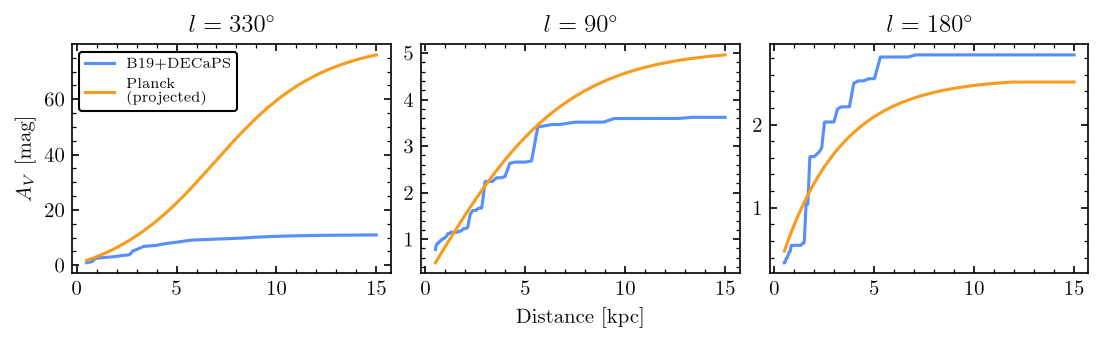

In [175]:
sightlines = (330, 90, 180)
distances = np.linspace(500, 15000, num=1000)

fig, ax = plt.subplots(
    ncols=len(sightlines), figsize=(plots.TEXTWIDTH, plots.TEXTWIDTH * 0.3)
)

for an_ax, l in zip(ax, sightlines):
    coord_maps = SkyCoord(
        l=l * u.deg, b=0 * u.deg, distance=distances * u.pc, frame="galactic"
    )

    extinctions = 3.1 * planck_3d.query(coord_maps, mode="expon")

    bayestar_dust = 3.1 * 0.84 * bayestar.query(coord_maps, mode="best")
    decaps_dust = 3.1 * decaps.query(coord_maps)
    base_dust = np.where(np.isfinite(decaps_dust), decaps_dust, bayestar_dust)

    an_ax.plot(distances*1e-3, base_dust, label="B19+DECaPS", color=plots.cycle6[0])
    an_ax.plot(distances*1e-3, extinctions, label="Planck\n(projected)", color=plots.cycle6[1])
    an_ax.set(title=f"$l={l:.0f}^\\circ$")

ax[0].legend()
ax[0].set(ylabel="$A_V$ [mag]")
ax[1].set(xlabel="Distance [kpc]")
# plt.yscale("log")

fig.savefig(plots.FIGS_PRES / "planck_map_sightlines.png")